In [1]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
import sys
sys.path.insert(0, '../scripts')
from plotting import *
from common_defs import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
[0.   0.   0.25 0.42 0.53 0.94]
3.10.8


In [2]:
def get_lb_pair(jets, leptons, bhadrons):
    
    jets_sel = jets[jets.pt > 30]
    
    # Build Jet x Bhadron pairs: events -> jets -> bhadrons
    pairs_jb = ak.cartesian(
        {"j": jets_sel, "bh": bhadrons},
        axis=1,
        nested=True,
    )
    
    dr_jb = pairs_jb["j"].deltaR(pairs_jb["bh"])
    
    has_bhadron = ak.any(dr_jb < 0.4, axis=2)
    
    bjets = jets_sel[has_bhadron]
    
    leptons_sel = leptons[leptons.pt > 25]
    
    # events -> leptons -> bjets
    pairs_lb = ak.cartesian(
        {"l": leptons_sel, "b": bjets},
        axis=1,
        nested=True,
    )
    
    dr_lb = ak.fill_none(pairs_lb["l"].deltaR(pairs_lb["b"]), np.inf)
    idx = ak.argmin(dr_lb, axis=2)                 # events→L
    best_b = bjets[idx]
    drmin_lb = ak.min(dr_lb, axis=2, initial=np.inf)

    valid_pair = (
    ~ak.is_none(best_b, axis=1)
    & (drmin_lb > 0.4)
    )

    sel = ak.any(valid_pair, axis=1)
    
    m_lb = (leptons_sel + best_b).mass
    m_lb = m_lb[valid_pair]
    
    return m_lb[sel, 0], sel

In [3]:
ttbar_jets = ak.from_parquet(lhayDir + '/ttbar_NLO_100k_eta4p5_pt20.parquet')
order = ak.argsort(ttbar_jets.pt, axis=1, ascending=False)
jets = ttbar_jets[order]

bhadrons = ak.from_parquet(lhayDir + '/ttbar_100k/ttbar_NLO_100k_bhadrons.parquet')
leptons = ak.from_parquet(lhayDir + '/ttbar_100k/ttbar_NLO_100k_leptons.parquet')



In [4]:
obsDict = {}
njets = max(ak.num(jets.pt, axis=1))-1

nosel = (ak.num(jets.pt, axis=1)>-5)

sel_twojets = (ak.num(jets.pt, axis=1)>1)
sel_jets_twojets = jets[sel_twojets]

sel_onejet = (ak.num(jets.pt, axis=1)>0)
sel_jets_onejet = jets[sel_onejet]

mlb, sel_lb = get_lb_pair(jets, leptons, bhadrons)

quantity="m_{tt}"
sel_ttjets = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel_ttjets]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass


#obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}","units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.75,1.25], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "logy": True}
obsDict["njets"] = {"name": r'N_{\mathrm{jets}}', "xmin": 0, "xmax": 20,"units": r"", "xmax": njets,"numbins": njets, "ratioLim": [0.75,1.25], "obs": ak.num(jets.pt, axis=1), "sel":nosel, "logx":False, "logy": True, "ymin": 1e-4, "ymax": 1.5}
#obsDict["ptlead"] = {"name": "p_{T,j_0}", "xmin": 20,"units": r"\mathrm{[GeV]}", "xmax": 500, "numbins": 20, "ratioLim": [0.75,1.25], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "logy": True}
obsDict["ht"] = {"name": r'H_\mathrm{T}', "xmin": 50, "xmax": 2500,"units": r"\mathrm{[GeV]}", "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(jets.pt, axis=-1), "sel": nosel, "logx":True, "logy": True, "ymin": 1e-4, "ymax": 2.5}
#obsDict["mtt"] = {"name": "m_{tt}", "xmin": 0, "xmax": 2000,"units": r"\mathrm{[GeV]}", "numbins": 20, "ratioLim": [0.75,1.25], "obs": mtt, "sel": sel_ttjets, "logx":False, "logy": False, "ymin": 0, "ymax": 0.2}
obsDict["mlb"] = {"name": "m_{lb}", "xmin": 0, "xmax": 250,"units": r"\mathrm{[GeV]}", "numbins": 24, "ratioLim": [0.75,1.25], "obs": mlb, "sel": sel_lb, "logx":False, "logy": False, "ymin": 1e-4, "ymax": 0.2}
#obsDict["ptrat"] = {"name": "p_{T0}/p_{T1}", "xmin": 1,"units": r"", "xmax": 4.5, "numbins": 14, "ratioLim": [0.75,1.25], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "logy": True}

In [5]:
processDict = {}
processDict["TTbar"] = {"name": r"$t\bar{t}$", "weights": weights_orig_ttbar}

In [10]:
comparisonDict = {}
comparisonDict["stages"] = {"weights": ["ttbar_hp_df", "ttbar_ps_df", "ttbar_had_df"], "maxCellRadius":100}
comparisonDict["EMDvsAndersen"] = {"weights": ["ttbar_had_df", "ttbar_jeppe_df", "ttbar_jeppeV2_df"], "maxCellRadius":100}

In [11]:
from plotting import * 
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]
    datasets = []
    for sample in rw_dict_strings:
        datasets.append(dataFrames[sample])
            
    directory = f"../plots_ttbar/radius"
    plot_radii(datasets, directory, comparison, comparisonDict)

$\beta=1$ HS  R for 0.75 RW  25.968
$\beta=1$ HS  R for 0.5 RW  21.716
$\beta=1$ HS  R for 0.25 RW  18.32
$\beta=1$ PS  R for 0.75 RW  35.951
$\beta=1$ PS  R for 0.5 RW  29.288
$\beta=1$ PS  R for 0.25 RW  23.966
$\beta=1$ HAD  R for 0.75 RW  35.208
$\beta=1$ HAD  R for 0.5 RW  29.521
$\beta=1$ HAD  R for 0.25 RW  24.979
../plots_ttbar/radius/radii_stages
$\beta=1$ HAD  R for 0.75 RW  35.208
$\beta=1$ HAD  R for 0.5 RW  29.521
$\beta=1$ HAD  R for 0.25 RW  24.979
Andersen $et$ $al.$ R for 0.75 RW  522.372
Andersen $et$ $al.$ R for 0.5 RW  408.374
Andersen $et$ $al.$ R for 0.25 RW  317.308
V2 Andersen $et$ $al.$ R for 0.75 RW  464.792
V2 Andersen $et$ $al.$ R for 0.5 RW  360.582
V2 Andersen $et$ $al.$ R for 0.25 RW  277.333
../plots_ttbar/radius/radii_EMDvsAndersen


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
rwFracs = [0.25, 0.75]
for comparison in comparisonDict:
    for observable in obsDict:
        for rwFrac in rwFracs:       
            rw_dict_strings = comparisonDict[comparison]["weights"]

            processes = []
            datasets = []
            for sample in rw_dict_strings:
                datasets.append(dataFrames[sample])
                processes.append(dataFrames[sample]["process"])

            processWeights = processDict[processes[0]]["weights"]
            processTitle = processDict[processes[0]]["name"]
            isSameProcess = True
            for process in processes:
                if process != processes[0]:
                    print("Mixed processes -- this script requires rewriting to work in this context")
                    isSameProcess= False
                    break
            if not isSameProcess:
                break

            plot_diff_rw(obsDict[observable], datasets, processWeights, process_title = processTitle, title = comparison, channel = processes[0], rwFrac=rwFrac, obsName = observable)


stages
{'process': 'TTbar', 'df':    radius  fraction                                            weights
0       1      0.00  [181.75336200000007, 181.75336200000007, 181.7...
1      18      0.00  [181.75336200000007, 181.75336200000007, 181.7...
2      25      0.25  [181.75336200000007, 181.75336200000007, 181.7...
3      28      0.42  [181.75336200000007, 181.75336200000007, 181.7...
4      30      0.53  [181.75336200000007, 181.75336200000007, 181.7...
5      50      0.94  [36.350672400000015, 181.75336200000007, 36.35..., 'xmd': array([0.        , 0.00337463, 0.627123  , 1.12000536, 1.45166362,
       3.10868861]), 'title': '$t\\bar{t}$ $\\beta=1$ HAD ', 'color': '#ff9d00', 'marker': '^', 'line': '-'}
TTbar


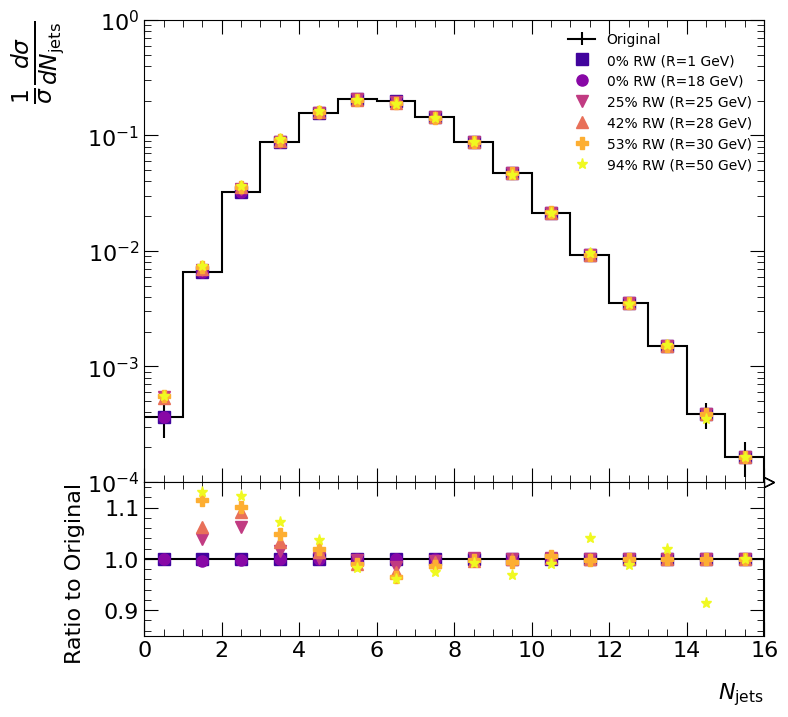

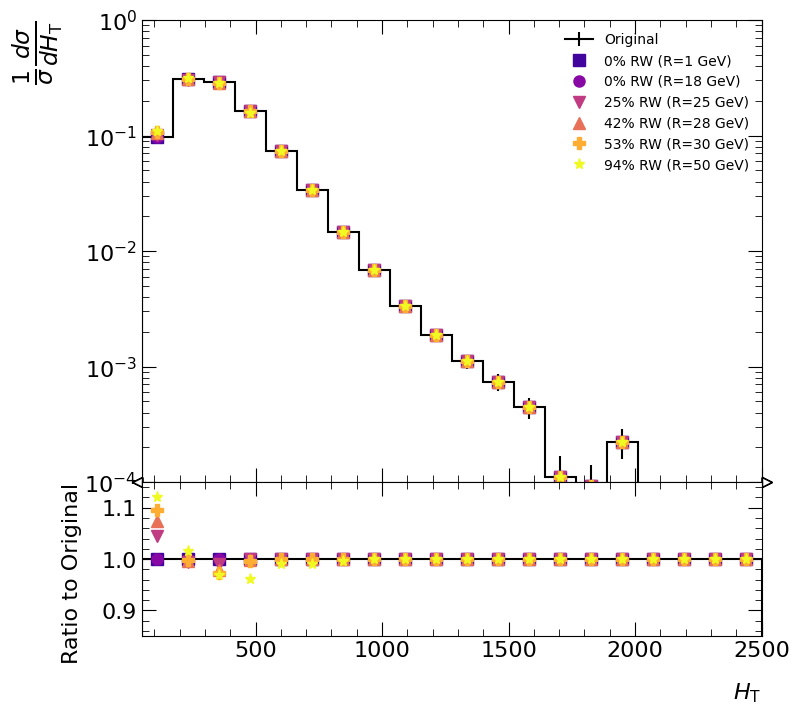

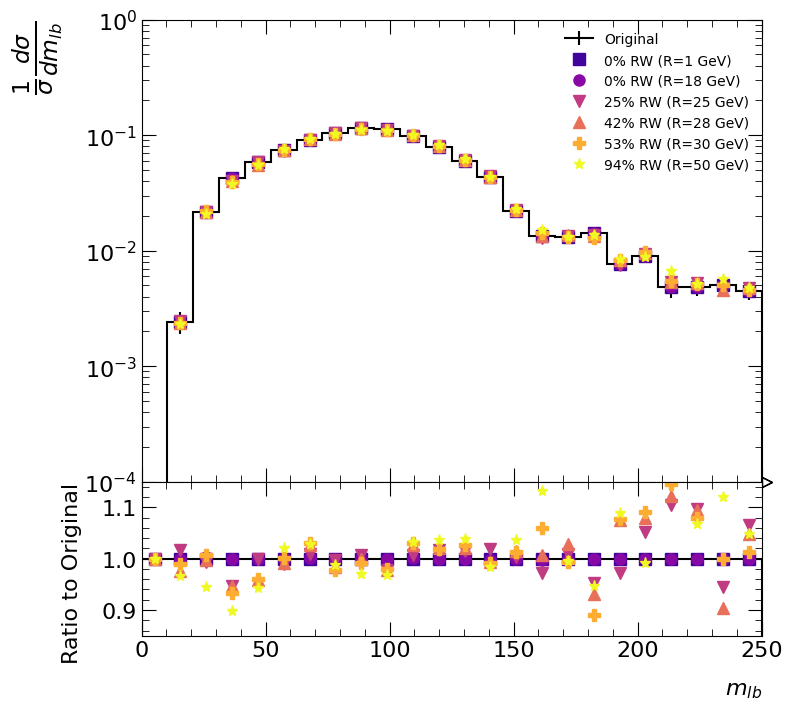

{'process': 'TTbar', 'df':          radius  fraction                                            weights
0    200.000000      0.01  [0.012491640000000004, 0.012491640000000004, 0...
1    206.678209      0.01  [0.012491640000000004, 0.012491640000000004, 0...
2    213.579411      0.02  [0.012491640000000004, 0.012491640000000004, 0...
3    220.711050      0.03  [0.012491640000000004, 0.012491640000000004, 0...
4    228.080823      0.04  [0.012491640000000004, 0.012491640000000004, 0...
5    235.696680      0.05  [0.012491640000000004, 0.012491640000000004, 0...
6    243.566839      0.07  [0.012491640000000004, 0.012491640000000004, 0...
7    251.699790      0.09  [0.012491640000000004, 0.012491640000000004, 0...
8    260.104309      0.10  [0.012491640000000004, 0.012491640000000004, 0...
9    268.789464      0.12  [0.012491640000000004, 0.012491640000000004, 0...
10   277.764625      0.15  [0.012491640000000004, 0.012491640000000004, 0...
11   287.039476      0.17  [0.012491640000000004,

In [ ]:
# for dataFrame in dataFrames:
for comparison in comparisonDict:
    print(comparison)
    for sample in rw_dict_strings:
        dataset = dataFrames[sample]
        process = dataFrames[sample]["process"]
        print(dataset)
        print(process)
        rw_dict_strings = comparisonDict[comparison]["weights"]
        for observable in obsDict:
            xmin = obsDict[observable]["xmin"]
            xmax = obsDict[observable]["xmax"]
            numbins = obsDict[observable]["numbins"]
            obs_str = obsDict[observable]["name"]
            obs= obsDict[observable]["obs"]
            sel = obsDict[observable]["sel"]
            ratioLim = obsDict[observable]["ratioLim"]
            title = dataFrames[dataFrame]["title"]
    
            process_str = processDict[process]["name"]
            processWeights = processDict[process]["weights"]
            dataset = dataFrames[sample]
            plot_same_rw_all(obs, dataset["df"], processWeights, numbins, xmin, xmax, sel=sel, obs_str=obs_str, obs_title = observable, title = title)
